
=== Average daily soil moisture and temperature per farm ===
+--------+----------+------------------+------------------+
|farm_id |event_date|avg_soil_moisture |avg_temperature   |
+--------+----------+------------------+------------------+
|FARM_001|2023-01-04|NULL              |73.4              |
|FARM_001|2023-01-05|NULL              |28.84             |
|FARM_001|2023-01-09|73.42             |30.5              |
|FARM_001|2023-01-10|74.02             |NULL              |
|FARM_001|2023-01-15|NULL              |61.98             |
|FARM_001|2023-01-16|NULL              |43.07             |
|FARM_001|2023-01-22|68.48             |NULL              |
|FARM_001|2023-01-24|NULL              |56.36             |
|FARM_001|2023-01-25|NULL              |9.74              |
|FARM_001|2023-01-29|73.11             |NULL              |
|FARM_001|2023-02-02|52.71             |NULL              |
|FARM_001|2023-02-03|66.66             |71.98             |
|FARM_001|2023-02-06|60.7             

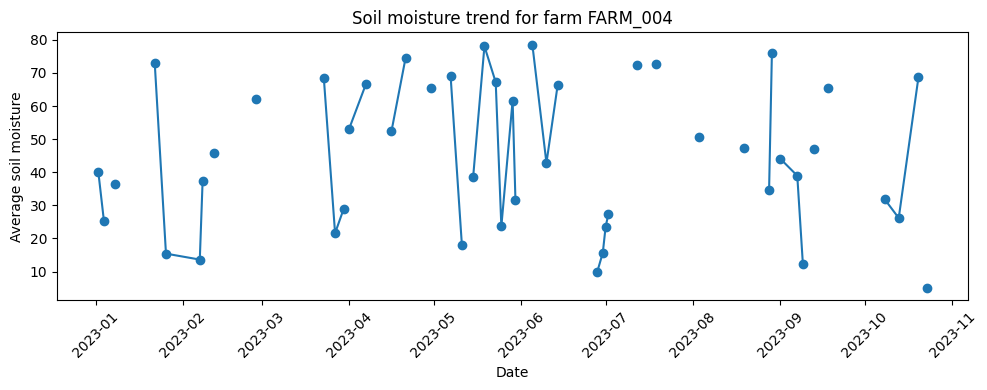

+--------------------+----------------------------------------+-------------------------------------------------------------------------+--------------+-------------------+
|dataset_name        |source_datasets                         |target_path                                                              |schema_version|pipeline_run_ts    |
+--------------------+----------------------------------------+-------------------------------------------------------------------------+--------------+-------------------+
|daily_farm_stats    |silver.soil_moisture, silver.temperature|/Users/dev/PycharmProjects/jup/mnt/agri/gold/parquet/daily_farm_stats    |1.0           |2025-11-19 22:15:50|
|low_moisture_streaks|gold.daily_farm_stats                   |/Users/dev/PycharmProjects/jup/mnt/agri/gold/parquet/low_moisture_streaks|1.0           |2025-11-19 22:15:50|
+--------------------+----------------------------------------+------------------------------------------------------------------------

In [8]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.window import Window

# Optional (for metadata)
from datetime import datetime

# Optional (for chart)
import matplotlib.pyplot as plt

# ---------------------------
# 1. Spark session
# ---------------------------
spark = (
    SparkSession.builder
    .appName("ARE_Gold_Analytics")
    .getOrCreate()
)

# Quiet down logs for demo
spark.sparkContext.setLogLevel("ERROR")  # or "WARN"

silver_path = "/Users/dev/PycharmProjects/jup/mnt/agri/silver/parquet"
gold_path   = "/Users/dev/PycharmProjects/jup/mnt/agri/gold/parquet"

# ---------------------------
# 2. Load silver data
# ---------------------------
soil = spark.read.parquet(f"{silver_path}/soil_moisture")
temp = spark.read.parquet(f"{silver_path}/temperature")

# Derive event_date
soil = soil.withColumn("event_date", F.to_date("reading_ts"))
temp = temp.withColumn("event_date", F.to_date("reading_ts"))

# ---------------------------
# 3. Daily farm stats
# ---------------------------

# 3.1 Average daily soil moisture & temperature per farm
daily_soil = (
    soil
    .groupBy("farm_id", "event_date")
    .agg(F.avg("reading_value").alias("avg_soil_moisture"))
)

daily_temp = (
    temp
    .groupBy("farm_id", "event_date")
    .agg(F.avg("reading_value").alias("avg_temperature"))
)

daily_farm_stats = (
    daily_soil
    .join(daily_temp, ["farm_id", "event_date"], "full_outer")
)

# ---------------------------
# 4. Low moisture streaks
# ---------------------------
low_moisture_days = (
    daily_soil
    .withColumn("is_low", F.col("avg_soil_moisture") < 30)
)

# Use a window to detect streaks
w = Window.partitionBy("farm_id").orderBy("event_date")

low_moisture_days = (
    low_moisture_days
    .withColumn("rn", F.row_number().over(w))
    .withColumn("grp", F.date_sub("event_date", F.col("rn")))
)

streaks = (
    low_moisture_days
    .filter(F.col("is_low") == True)
    .groupBy("farm_id", "grp")
    .agg(
        F.count("*").alias("consecutive_days"),
        F.min("event_date").alias("start_date"),
        F.max("event_date").alias("end_date")
    )
    .filter(F.col("consecutive_days") >= 3)
)

# ---------------------------
# 4. PRINT requested outputs
# ---------------------------
print("\n=== Average daily soil moisture and temperature per farm ===")
daily_farm_stats.orderBy("farm_id", "event_date").show(50, truncate=False)

print("\n=== Farms with low soil moisture (<30%) for 3+ consecutive days ===")
streaks.orderBy("farm_id", "start_date").show(50, truncate=False)


# ---------------------------
# 5. Persist gold outputs
# ---------------------------
(
    daily_farm_stats
    .write
    .mode("overwrite")
    .parquet(f"{gold_path}/daily_farm_stats")
)

(
    streaks
    .write
    .mode("overwrite")
    .parquet(f"{gold_path}/low_moisture_streaks")
)

# ======================================================
# 6. OPTIONAL BONUS – Visualisation of moisture trends
# ======================================================

# Pick one farm with data to plot moisture trend
sample_farm_row = (
    daily_farm_stats
    .filter(F.col("avg_soil_moisture").isNotNull())
    .select("farm_id")
    .distinct()
    .limit(1)
    .collect()
)

if sample_farm_row:
    sample_farm_id = sample_farm_row[0]["farm_id"]

    moisture_trend_pdf = (
        daily_farm_stats
        .filter(F.col("farm_id") == sample_farm_id)
        .orderBy("event_date")
        .select("event_date", "avg_soil_moisture")
        .toPandas()
    )

    if not moisture_trend_pdf.empty:
        plt.figure(figsize=(10, 4))
        plt.plot(
            moisture_trend_pdf["event_date"],
            moisture_trend_pdf["avg_soil_moisture"],
            marker="o"
        )
        plt.title(f"Soil moisture trend for farm {sample_farm_id}")
        plt.xlabel("Date")
        plt.ylabel("Average soil moisture")
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()
    else:
        print("[INFO] No moisture data available for sample farm to plot.")
else:
    print("[INFO] No farm found with non-null avg_soil_moisture for plotting.")

# ======================================================
# 7. OPTIONAL BONUS – Metadata / Lineage example
# ======================================================

schema_version = "1.0"
pipeline_run_ts = datetime.utcnow().strftime("%Y-%m-%d %H:%M:%S")

metadata_rows = [
    (
        "daily_farm_stats",                          # dataset_name
        "silver.soil_moisture, silver.temperature",  # source_datasets
        f"{gold_path}/daily_farm_stats",             # target_path
        schema_version,
        pipeline_run_ts
    ),
    (
        "low_moisture_streaks",
        "gold.daily_farm_stats",
        f"{gold_path}/low_moisture_streaks",
        schema_version,
        pipeline_run_ts
    )
]

metadata_columns = [
    "dataset_name",
    "source_datasets",
    "target_path",
    "schema_version",
    "pipeline_run_ts"
]

metadata_df = spark.createDataFrame(metadata_rows, metadata_columns)

# Optionally show in notebook
metadata_df.show(truncate=False)

(
    metadata_df
    .write
    .mode("overwrite")
    .parquet(f"{gold_path}/metadata")
)

spark.stop()



=== Average daily soil moisture and temperature per farm ===
+--------+----------+------------------+------------------+
|farm_id |event_date|avg_soil_moisture |avg_temperature   |
+--------+----------+------------------+------------------+
|FARM_001|2023-01-04|NULL              |73.4              |
|FARM_001|2023-01-05|NULL              |28.84             |
|FARM_001|2023-01-09|73.42             |30.5              |
|FARM_001|2023-01-10|74.02             |NULL              |
|FARM_001|2023-01-15|NULL              |61.98             |
|FARM_001|2023-01-16|NULL              |43.07             |
|FARM_001|2023-01-22|68.48             |NULL              |
|FARM_001|2023-01-24|NULL              |56.36             |
|FARM_001|2023-01-25|NULL              |9.74              |
|FARM_001|2023-01-29|73.11             |NULL              |
|FARM_001|2023-02-02|52.71             |NULL              |
|FARM_001|2023-02-03|66.66             |71.98             |
|FARM_001|2023-02-06|60.7             

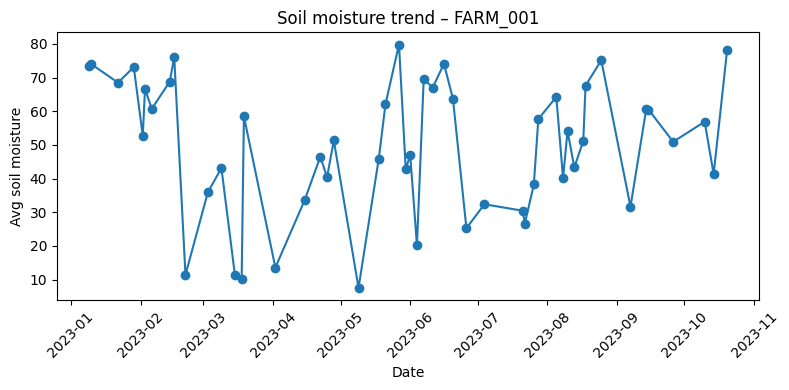


=== Metadata / Lineage Information ===
+--------------------+----------------------------------------------------------------------------------------------------------------------------------------+--------------+--------------------------+
|table_name          |source_tables_or_paths                                                                                                                  |schema_version|run_timestamp_utc         |
+--------------------+----------------------------------------------------------------------------------------------------------------------------------------+--------------+--------------------------+
|daily_farm_stats    |/Users/dev/PycharmProjects/jup/mnt/agri/silver/parquet/soil_moisture, /Users/dev/PycharmProjects/jup/mnt/agri/silver/parquet/temperature|v1.0          |2025-11-19T22:15:52.936969|
|low_moisture_streaks|/Users/dev/PycharmProjects/jup/mnt/agri/gold/parquet/daily_farm_stats                                                             

In [9]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.window import Window
from datetime import datetime

spark = (
    SparkSession.builder
    .appName("ARE_Gold_Analytics")
    .getOrCreate()
)

# Keep logs sensible for demo
spark.sparkContext.setLogLevel("ERROR")

silver_path = "/Users/dev/PycharmProjects/jup/mnt/agri/silver/parquet"
gold_path   = "/Users/dev/PycharmProjects/jup/mnt/agri/gold/parquet"

# ---------------------------
# 1. Load Silver Tables
# ---------------------------
soil = spark.read.parquet(f"{silver_path}/soil_moisture")
temp = spark.read.parquet(f"{silver_path}/temperature")

# Derive event_date
soil = soil.withColumn("event_date", F.to_date("reading_ts"))
temp = temp.withColumn("event_date", F.to_date("reading_ts"))

# ---------------------------
# 2. Daily averages per farm
# ---------------------------
daily_soil = (
    soil.groupBy("farm_id", "event_date")
        .agg(F.avg("reading_value").alias("avg_soil_moisture"))
)

daily_temp = (
    temp.groupBy("farm_id", "event_date")
        .agg(F.avg("reading_value").alias("avg_temperature"))
)

daily_farm_stats = (
    daily_soil.join(daily_temp, ["farm_id", "event_date"], "full_outer")
)

# ---------------------------
# 3. Low moisture streaks
# ---------------------------
low_moisture_days = daily_soil.withColumn(
    "is_low",
    F.col("avg_soil_moisture") < 30
)

w = Window.partitionBy("farm_id").orderBy("event_date")

low_moisture_days = (
    low_moisture_days
    .withColumn("rn", F.row_number().over(w))
    # trick: date - row_number gives same grp for consecutive days
    .withColumn("grp", F.date_sub("event_date", F.col("rn")))
)

streaks = (
    low_moisture_days
    .filter(F.col("is_low") == True)
    .groupBy("farm_id", "grp")
    .agg(
        F.count("*").alias("consecutive_days"),
        F.min("event_date").alias("start_date"),
        F.max("event_date").alias("end_date")
    )
    .filter(F.col("consecutive_days") >= 3)
    .drop("grp")
)

# ---------------------------
# 4. PRINT requested outputs
# ---------------------------
print("\n=== Average daily soil moisture and temperature per farm ===")
daily_farm_stats.orderBy("farm_id", "event_date").show(50, truncate=False)

print("\n=== Farms with low soil moisture (<30%) for 3+ consecutive days ===")
streaks.orderBy("farm_id", "start_date").show(50, truncate=False)

# ---------------------------
# 5. Optional chart: moisture trend
# ---------------------------
try:
    import matplotlib.pyplot as plt

    # Pick one sample farm for visualisation
    sample_farm_row = (
        daily_soil.select("farm_id")
        .distinct()
        .orderBy("farm_id")
        .limit(1)
        .collect()
    )

    if sample_farm_row:
        sample_farm = sample_farm_row[0]["farm_id"]
        print(f"\n[Chart] Plotting soil moisture trend for farm: {sample_farm}")

        trend_pdf = (
            daily_soil
            .filter(F.col("farm_id") == sample_farm)
            .orderBy("event_date")
            .toPandas()
        )

        if not trend_pdf.empty:
            plt.figure(figsize=(8, 4))
            plt.plot(trend_pdf["event_date"], trend_pdf["avg_soil_moisture"], marker="o")
            plt.title(f"Soil moisture trend – {sample_farm}")
            plt.xlabel("Date")
            plt.ylabel("Avg soil moisture")
            plt.xticks(rotation=45)
            plt.tight_layout()
            plt.show()
        else:
            print("[Chart] No data available for selected farm.")
    else:
        print("[Chart] No farms available to plot.")
except Exception as e:
    print(f"[Chart] Skipping chart creation due to error: {e}")

# ---------------------------
# 6. Metadata / Lineage example
# ---------------------------
run_ts = datetime.utcnow().isoformat()

lineage_rows = [
    (
        "daily_farm_stats",
        f"{silver_path}/soil_moisture, {silver_path}/temperature",
        "v1.0",
        run_ts
    ),
    (
        "low_moisture_streaks",
        f"{gold_path}/daily_farm_stats",
        "v1.0",
        run_ts
    ),
]

lineage_df = spark.createDataFrame(
    lineage_rows,
    ["table_name", "source_tables_or_paths", "schema_version", "run_timestamp_utc"]
)

print("\n=== Metadata / Lineage Information ===")
lineage_df.show(truncate=False)

# Persist lineage info as well
(
    lineage_df
    .write
    .mode("overwrite")
    .parquet(f"{gold_path}/_lineage")
)

# ---------------------------
# 7. Persist gold outputs
# ---------------------------
(
    daily_farm_stats
    .write
    .mode("overwrite")
    .parquet(f"{gold_path}/daily_farm_stats")
)

(
    streaks
    .write
    .mode("overwrite")
    .parquet(f"{gold_path}/low_moisture_streaks")
)

spark.stop()
